# 01 — Exploratory Data Analysis

Before building any model, this notebook looks at the data itself: how balanced
the activity classes are, what the raw sensor signals look like for each activity,
and which activities are likely to be hard to tell apart.

The last point matters most. Some activities produce almost identical sensor
readings (sitting vs standing are both still; the accelerometer barely moves).
Spotting that here tells us in advance where a classifier will struggle, and it
is exactly what the confusion matrix in Step 3 will confirm.

In [1]:
import sys
from pathlib import Path

# Make the repo's src/ importable from inside notebooks/.
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_features, load_raw_signals, ACTIVITY_LABELS

sns.set_theme(style="whitegrid", context="notebook")

# A fixed colour per activity, reused across every plot for consistency.
ACTIVITIES = [ACTIVITY_LABELS[i] for i in range(1, 7)]
PALETTE = dict(zip(ACTIVITIES, sns.color_palette("tab10", 6)))

# Load both representations.
X_feat_tr, y_tr, subj_tr = load_features("train")
X_feat_te, y_te, subj_te = load_features("test")
X_raw_tr, _, _ = load_raw_signals("train")

print(f"Feature matrix (train): {X_feat_tr.shape}")
print(f"Raw signals   (train): {X_raw_tr.shape}")
print(f"Activities: {ACTIVITIES}")

Feature matrix (train): (7352, 561)
Raw signals   (train): (7352, 128, 9)
Activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## 1. Class distribution

If some activities are much rarer than others, plain accuracy becomes misleading:
a model can look good just by favouring the common classes. That is why the
evaluation in Step 3 leads with macro-F1, which weights every class equally.

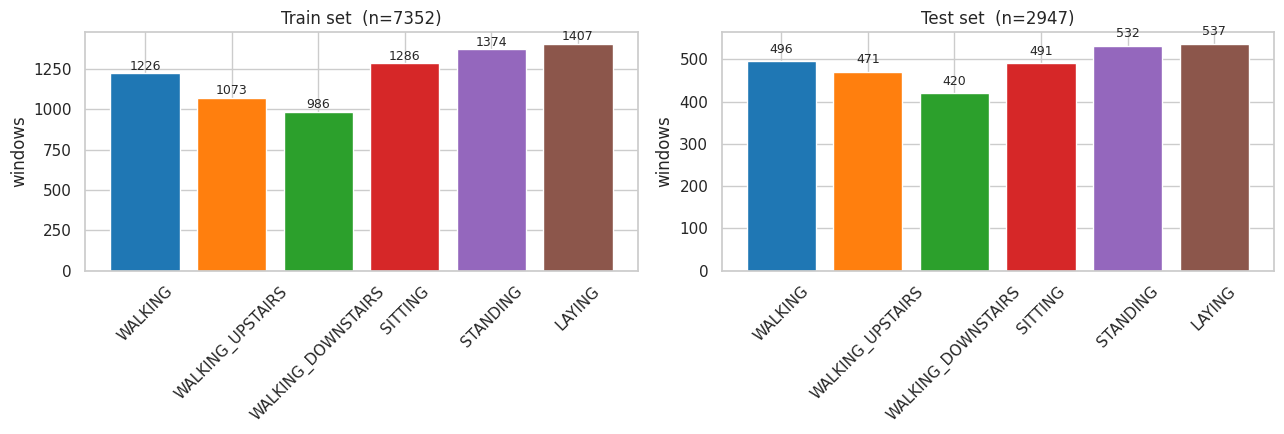

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, y, title in [(axes[0], y_tr, "Train"), (axes[1], y_te, "Test")]:
    counts = [np.sum(y == i) for i in range(1, 7)]
    ax.bar(ACTIVITIES, counts, color=[PALETTE[a] for a in ACTIVITIES])
    ax.set_title(f"{title} set  (n={len(y)})")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("windows")
    for i, c in enumerate(counts):
        ax.text(i, c + 20, str(c), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

The classes are reasonably balanced but not perfectly — laying and the static
postures have somewhat more samples than the walking variants. Not severe, but
enough to prefer macro-F1 over raw accuracy.

## 2. The split is subject-independent

This is the methodological core of the project. The 21 training subjects and
9 test subjects never overlap, so every reported number reflects how well the
model generalises to **people it has never seen** — not just new windows from
people it already learned. Random window splits, common in tutorials, leak the
same subject into both sides and inflate accuracy.

Train subjects (21): [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test  subjects (9): [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Overlap: none


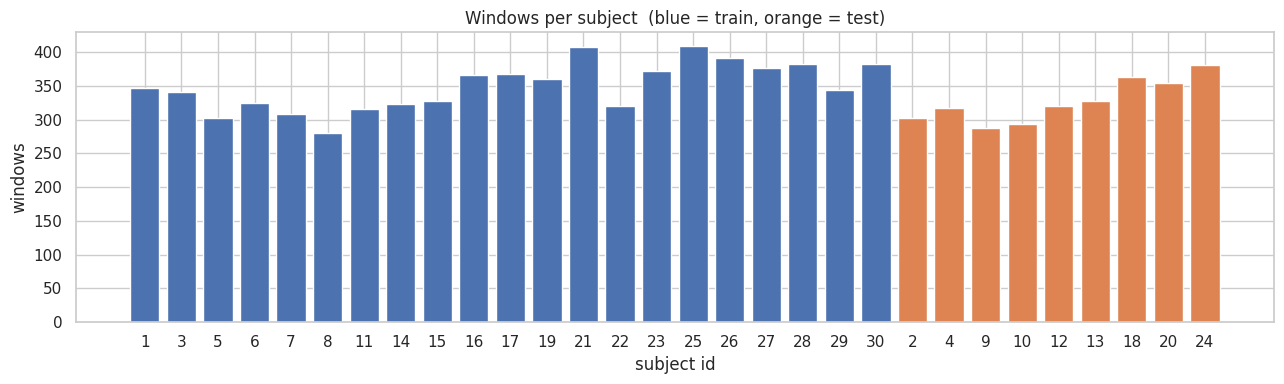

In [3]:
train_subjects = sorted(set(subj_tr))
test_subjects = sorted(set(subj_te))
overlap = set(train_subjects) & set(test_subjects)

print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Test  subjects ({len(test_subjects)}): {test_subjects}")
print(f"Overlap: {overlap or 'none'}")

# Windows contributed by each subject.
fig, ax = plt.subplots(figsize=(13, 4))
all_subjects = train_subjects + test_subjects
counts = ([np.sum(subj_tr == s) for s in train_subjects] +
          [np.sum(subj_te == s) for s in test_subjects])
colors = (["#4c72b0"] * len(train_subjects) +
          ["#dd8452"] * len(test_subjects))
ax.bar([str(s) for s in all_subjects], counts, color=colors)
ax.set_xlabel("subject id")
ax.set_ylabel("windows")
ax.set_title("Windows per subject  (blue = train, orange = test)")
plt.tight_layout()
plt.show()

## 3. What the raw signals look like

Each window is 2.56 seconds of movement (128 samples at 50 Hz). Plotting the
total-acceleration magnitude for one window of each activity shows the intuition
a model has to learn: walking activities are strongly periodic (the gait cycle),
while static postures are nearly flat lines.

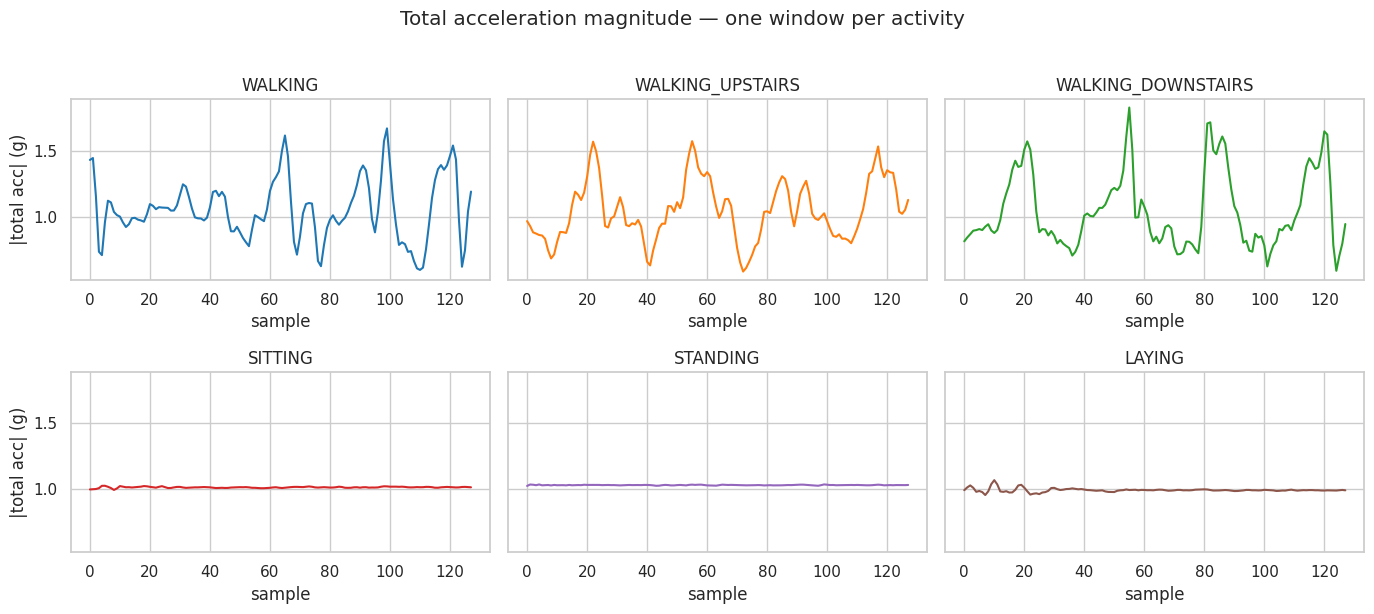

In [4]:
def acc_magnitude(window):
    # total_acc channels are the last three (x, y, z).
    tx, ty, tz = window[:, 6], window[:, 7], window[:, 8]
    return np.sqrt(tx**2 + ty**2 + tz**2)

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for i, act in enumerate(range(1, 7)):
    ax = axes.flat[i]
    # First window belonging to this activity in the training set.
    idx = np.where(y_tr == act)[0][0]
    mag = acc_magnitude(X_raw_tr[idx])
    name = ACTIVITY_LABELS[act]
    ax.plot(mag, color=PALETTE[name])
    ax.set_title(name)
    ax.set_xlabel("sample")
    if i % 3 == 0:
        ax.set_ylabel("|total acc| (g)")
plt.suptitle("Total acceleration magnitude — one window per activity", y=1.02)
plt.tight_layout()
plt.show()

The three walking activities oscillate; sitting, standing and laying are almost
flat. So separating *moving* from *still* is easy. The hard part is telling the
still activities apart from each other, and the moving activities apart from each
other. The next cell zooms in on the first of those problems.

## 4. Where a classifier will struggle: sitting vs standing

Sitting and standing are both motionless. The raw signal splits into two parts:
**body acceleration** (movement, with gravity removed) and **total acceleration**
(movement plus the constant pull of gravity). Looking at body acceleration —
the movement itself — the two activities are nearly indistinguishable, because
neither involves any real motion. The mean signal of each axis lands almost on
top of each other.

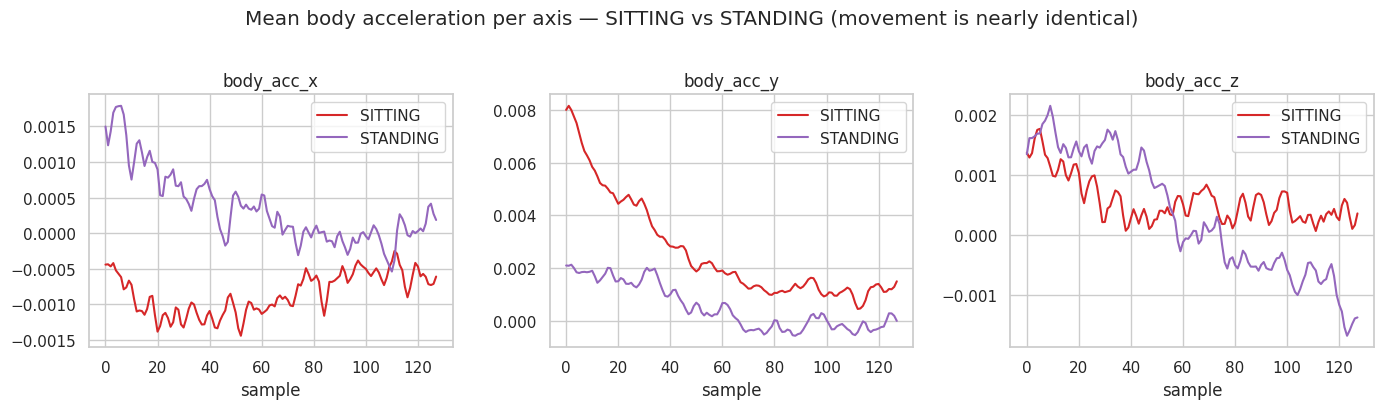

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axis_names = ["body_acc_x", "body_acc_y", "body_acc_z"]
axis_cols = [0, 1, 2]   # body_acc channels (gravity removed)

sit_idx = np.where(y_tr == 4)[0]      # SITTING
stand_idx = np.where(y_tr == 5)[0]    # STANDING

for ax, col, name in zip(axes, axis_cols, axis_names):
    sit_mean = X_raw_tr[sit_idx][:, :, col].mean(axis=0)
    stand_mean = X_raw_tr[stand_idx][:, :, col].mean(axis=0)
    ax.plot(sit_mean, label="SITTING", color=PALETTE["SITTING"])
    ax.plot(stand_mean, label="STANDING", color=PALETTE["STANDING"])
    ax.set_title(name)
    ax.set_xlabel("sample")
    ax.legend()
plt.suptitle("Mean body acceleration per axis — SITTING vs STANDING "
             "(movement is nearly identical)", y=1.02)
plt.tight_layout()
plt.show()

The lines sit almost on top of each other: as movement, sitting and standing are
the same thing — stillness. The only cue that separates them is *orientation*,
the direction of gravity in the total-acceleration signal, which shifts slightly
depending on posture. That cue is subtle and varies from person to person, so a
model evaluated on unseen subjects has very little reliable signal to go on. We
should expect sitting vs standing to be the main source of error in Step 3.

## 5. Feature-space overview (PCA)

Projecting the 561 engineered features down to two dimensions gives a rough map
of how separable the activities are. We expect the moving activities to spread
out and the still activities to bunch together, previewing the classifier's job.

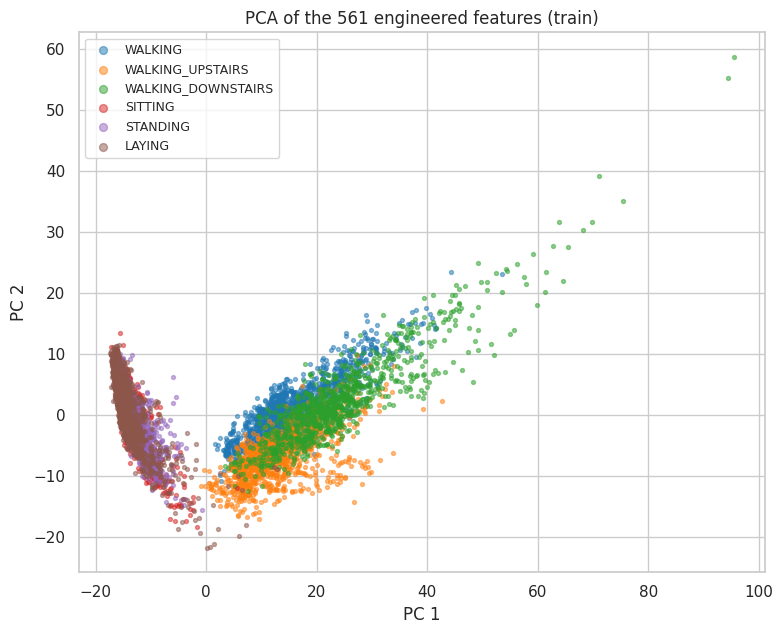

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Fit the scaler on train only — the same discipline used for modelling.
scaler = StandardScaler().fit(X_feat_tr)
X_scaled = scaler.transform(X_feat_tr)
pcs = PCA(n_components=2, random_state=0).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6.5))
for act in range(1, 7):
    name = ACTIVITY_LABELS[act]
    m = y_tr == act
    ax.scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5,
               label=name, color=PALETTE[name])
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA of the 561 engineered features (train)")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

A single line (roughly PC 1) already separates the moving activities on one side
from the still activities on the other. Within each group the classes overlap,
especially the still ones — consistent with what the raw signals showed.

## Takeaways

- The classes are mildly imbalanced, so evaluation leads with macro-F1.
- The train/test split is subject-independent, with no shared subjects.
- Moving vs still is easy; the hard cases are **sitting vs standing** and the
  three walking variants among themselves.
- These expectations give us something concrete to check against the confusion
  matrix in Step 3, rather than reading it cold.